# SIREN model diagnostics

Diagnostic notebook for the parameter-space classifier pipeline:

- **Section 1** applies the diagnostic recipe from `to_do/chat.md` to the vanilla SIREN backbone — weight spectra, pre/post-sine activation distributions, coordinate-scale audit, function sharpness, reconstruction fidelity curve.
- **Section 2** runs the same battery on the soft-Lipschitz checkpoint and overlays the two models so the comparison is direct.
- **Section 3** probes perturbation sensitivity: (3.1) random-noise shift curves over the standard $\varepsilon$ grid, (3.2) per-step PGD telemetry, (3.3) 2D decision-boundary slice.
- **Section 4** auto-populates a vanilla-vs-softlip summary table.

Heavy cells (PGD + boundary slice) are guarded by `RUN_HEAVY`. Set it to `True` once the lighter diagnostics look sane.

**Conventions.** All paths in §0 are top-of-notebook variables — repoint them without editing code. Fitting procedure matches `makeset.py` (SGD, lr 0.01, no grad clipping) so any `iters=5` number is apples-to-apples with what the downstream classifier sees.

## 0. Setup

Imports, path setup, configuration knobs, shared helpers. Run these cells first; nothing below will work without them.

In [1]:
"""0.1 Imports and path setup.

The notebook lives under SIREN_Vista/notebooks/ but imports modules from
SIREN_Vista/ directly. We prepend the repo root to sys.path so that
`import SIREN`, `import variants`, etc. resolve.
"""
import os
import sys
import json
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() \
    else Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPO_ROOT = REPO_ROOT.resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from SIREN import ModulatedSIREN, SineAffine, SinActivation  # noqa: E402
from train_classifier import Classifier                       # noqa: E402
from dataloader import get_mnist_loader                       # noqa: E402
from diagnostics import layer_sigmas                          # noqa: E402
from evaluate_reconstruction import batched_forward, ssim_2d_batch  # noqa: E402
import variants                                               # noqa: E402

print("repo root :", REPO_ROOT)
print("torch     :", torch.__version__, "| cuda ok:", torch.cuda.is_available())
print("variants  :", variants.available())

repo root : /home/omarg/SIREN_Vista
torch     : 2.0.1+cu117 | cuda ok: True
variants  : ['soft_lipschitz', 'vanilla']


In [2]:
"""0.2 Configuration.

Every path and size knob the notebook needs. Repoint any of these without
editing code further down.

`VANILLA_CKPT` default is the in-repo vanilla save path produced by
`trainer.py --variant vanilla`. A fallback to the pristine upstream
Parameter-Space-Attack-Suite checkpoint is also listed so Section 1 can
still run if you haven't trained a local vanilla yet.
"""
# ---- checkpoints --------------------------------------------------------
VANILLA_CKPT = REPO_ROOT / "model_mnist" / "vanilla" / "modSiren.pth"
VANILLA_CKPT_FALLBACK = Path("/home/omarg/SIREN_Vista/model_mnist/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/modSiren.pth")

SOFTLIP_CKPT = REPO_ROOT / "model_mnist" / "softlip_L30_lam1e+00_all_skip0" / "modSiren.pth"

# Classifier paths -- trained on the *matching* functaset produced by makeset.py
VANILLA_CLASSIFIER = REPO_ROOT / "runs" / "vanilla" / "mnist_classifier" / "best_classifier.pth"
SOFTLIP_CLASSIFIER = REPO_ROOT / "runs" / "softlip_L30_lam1e+00_all_skip0" / "mnist_classifier" / "best_classifier.pth"

# ---- soft-Lipschitz hyperparameters (for cap overlay in §2.1) -----------
# Read from the checkpoint's `variant_args` when available; these are just
# sensible defaults that match the standard softlip_L30_lam1e+00_all_skip0 run.
SOFTLIP_L_DEFAULT          = 30.0
SOFTLIP_APPLY_TO_DEFAULT   = "all"
SOFTLIP_SKIP_FIRST_DEFAULT = True

# ---- model architecture (used only if a checkpoint omits `model_args`) --
SIREN_HIDDEN_DEFAULT = 256
SIREN_DEPTH_DEFAULT  = 10
SIREN_MODDIM_DEFAULT = 512
SIREN_FREQ_DEFAULT   = 30.0
CLF_WIDTH_DEFAULT    = 512
CLF_DEPTH_DEFAULT    = 3

# ---- data / device ------------------------------------------------------
DATA_ROOT   = REPO_ROOT.parent  # /home/omarg -> MNIST expects ../data from here
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SEED        = 0

# ---- sample / grid sizes ------------------------------------------------
N_DIAG_SAMPLES    = 8    # images used in §1.2, §1.4, §2.2, §2.3
N_FIDELITY_IMAGES = 64   # images used in the PSNR vs iters curves (§1.5, §2.5)
N_PERT_SAMPLES    = 16   # §3.1 random-noise sensitivity
N_PGD_SAMPLES     = 4    # §3.2 PGD trajectory (one plot per sample)
N_BOUNDARY_GRID   = 21   # §3.3: 21x21 = 441 fits per model per anchor

# inner-loop budget for all "short" fits. Matches makeset --iters 5 default
FIT_STEPS_FAST  = 5
FIT_STEPS_SLOW  = 200  # fidelity ceiling
FIT_LR          = 0.01

# ---- heavy-cell toggle --------------------------------------------------
RUN_HEAVY = True  # flip to True to run §3.2 PGD and §3.3 boundary slice

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"DEVICE={DEVICE} SEED={SEED} RUN_HEAVY={RUN_HEAVY}")

DEVICE=cuda SEED=0 RUN_HEAVY=True


In [3]:
"""0.3 Shared helpers.

- load_siren / load_classifier : variant-aware checkpoint loading
- fit_phi                     : single-image inner loop (optionally with trajectory)
- batched_fit_phi             : B-image inner loop (reuses evaluate_reconstruction.batched_forward)
- hooked_forward              : context manager that captures pre-/post-sine
                                activations via forward hooks on SinActivation
- plotting helpers            : histogram grid, sigma bar, sensitivity curve
"""

# ---- checkpoint loading -------------------------------------------------
def _resolve_ckpt(primary, fallback=None):
    primary = Path(primary)
    if primary.exists():
        return primary
    if fallback is not None and Path(fallback).exists():
        print(f"[load] primary '{primary}' missing, falling back to '{fallback}'")
        return Path(fallback)
    return None


def load_siren(ckpt_path, device=DEVICE, height=28, width=28, voxels=False):
    """Load a ModulatedSIREN from a checkpoint produced by trainer.py.

    Uses `model_args` and `variant` / `variant_args` from the checkpoint
    when present; falls back to the module-level defaults otherwise.
    Returns (model, meta) where meta is a dict of the recovered metadata.
    """
    if ckpt_path is None:
        return None, None
    ckpt = torch.load(ckpt_path, map_location=device)
    model_args = ckpt.get("model_args", {}) or {}
    hidden = model_args.get("hidden_dim", SIREN_HIDDEN_DEFAULT)
    depth  = model_args.get("depth",       SIREN_DEPTH_DEFAULT)
    moddim = model_args.get("mod_dim",     SIREN_MODDIM_DEFAULT)
    model = ModulatedSIREN(
        height=height, width=width,
        hidden_features=hidden, num_layers=depth,
        modul_features=moddim, device=device,
    ).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    meta = {
        "variant":      ckpt.get("variant", "vanilla"),
        "variant_args": ckpt.get("variant_args", {}) or {},
        "model_args":   {"hidden_dim": hidden, "depth": depth, "mod_dim": moddim},
        "loss":         ckpt.get("loss"),
        "epoch":        ckpt.get("epoch"),
        "path":         str(ckpt_path),
    }
    return model, meta


def load_classifier(ckpt_path, in_features, device=DEVICE,
                    width=CLF_WIDTH_DEFAULT, depth=CLF_DEPTH_DEFAULT, num_classes=10):
    """Load a downstream Classifier MLP from train_classifier.py.

    `in_features` must match the SIREN's modul_features.
    """
    if ckpt_path is None or not Path(ckpt_path).exists():
        return None
    ckpt = torch.load(ckpt_path, map_location=device)
    sd = ckpt.get("state_dict", ckpt)
    clf = Classifier(width=width, depth=depth,
                     in_features=in_features, num_classes=num_classes).to(device)
    clf.load_state_dict(sd)
    clf.eval()
    for p in clf.parameters():
        p.requires_grad_(False)
    return clf


# ---- inner-loop fitting -------------------------------------------------
def fit_phi(model, image_flat, steps=FIT_STEPS_FAST, lr=FIT_LR,
            start_mod=None, trajectory=False, device=DEVICE):
    """Single-image inner fit, mirroring makeset.create_functaset.

    Args:
        image_flat: (H*W,) or (H*W,1) pixel target in [0, 1].
        start_mod : optional warm-start modulation (else zeros).
        trajectory: if True, returns a list of phi snapshots + a list of
            per-step MSE, in addition to the final phi.
    """
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    tgt = image_flat.to(device).view(-1, 1).float()

    if start_mod is None:
        phi = torch.zeros(model.modul_features, device=device)
    else:
        phi = start_mod.detach().clone().to(device).float()
    phi.requires_grad_(True)
    opt = optim.SGD([phi], lr=lr)
    mses, traj = [], []

    for _ in range(steps):
        opt.zero_grad()
        fitted = model(phi)
        loss = ((fitted - tgt) ** 2).mean()
        loss.backward()
        opt.step()
        mses.append(float(loss.item()))
        if trajectory:
            traj.append(phi.detach().clone())
    if trajectory:
        return phi.detach(), mses, traj
    return phi.detach(), mses


def batched_fit_phi(model, images_flat, steps=FIT_STEPS_FAST, lr=FIT_LR, device=DEVICE):
    """Fit B modulations in parallel via evaluate_reconstruction.batched_forward.

    Args:
        images_flat: (B, H*W) target pixels in [0, 1].
    Returns:
        phi_batch: (B, modul_features)
        mse_per  : (B,)  final per-image MSE
    """
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    tgt = images_flat.to(device).float()
    B = tgt.shape[0]
    tgt_for_loss = tgt.view(B, -1, 1)

    phi = torch.zeros(B, model.modul_features, device=device, requires_grad=True)
    opt = optim.SGD([phi], lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        fitted = batched_forward(model, phi)  # (B, N, 1)
        per_img = ((fitted - tgt_for_loss) ** 2).mean(dim=(1, 2))
        per_img.sum().backward()
        opt.step()
    with torch.no_grad():
        fitted = batched_forward(model, phi)
        per_img = ((fitted - tgt_for_loss) ** 2).mean(dim=(1, 2))
    return phi.detach(), per_img.detach()


# ---- activation hooks ---------------------------------------------------
@contextmanager
def hooked_forward(model):
    """Register forward hooks on every SinActivation and SineAffine.affine
    so that pre-sine z_l = freq*(W x + b + shift) and post-sine sin(z_l)
    can be inspected after a forward pass.

    Usage:
        with hooked_forward(model) as buf:
            _ = model(phi)
        # buf['sine.0.pre'], buf['sine.0.post'], buf['sine.0.affine']

    SinActivation is an explicit submodule on every SineAffine precisely
    so these hooks can be attached (see SIREN.py:6).
    """
    buf = {}
    handles = []
    sine_idx = 0
    for m in model.modules():
        if isinstance(m, SineAffine):
            idx = sine_idx
            affine = m.affine
            act    = m.activation
            def _mk_affine_hook(i):
                def _h(mod, inp, out):
                    buf[f"sine.{i}.affine"] = out.detach().clone()
                return _h
            def _mk_act_hook(i):
                def _h(mod, inp, out):
                    buf[f"sine.{i}.pre"]  = inp[0].detach().clone()
                    buf[f"sine.{i}.post"] = out.detach().clone()
                return _h
            handles.append(affine.register_forward_hook(_mk_affine_hook(idx)))
            handles.append(act   .register_forward_hook(_mk_act_hook(idx)))
            sine_idx += 1
    try:
        yield buf
    finally:
        for h in handles:
            h.remove()


# ---- plotting helpers ---------------------------------------------------
def _new_fig(rows=1, cols=1, figsize=None):
    if figsize is None:
        figsize = (4 * cols, 3 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    return fig, axes


def _psnr_from_mse(mse):
    mse = np.asarray(mse, dtype=np.float64)
    mse = np.clip(mse, 1e-12, None)
    return 10.0 * np.log10(1.0 / mse)


print("helpers loaded:",
      [f for f in ("load_siren","load_classifier","fit_phi","batched_fit_phi","hooked_forward") if f in globals()])

helpers loaded: ['load_siren', 'load_classifier', 'fit_phi', 'batched_fit_phi', 'hooked_forward']


In [4]:
"""0.4 Load models + a small MNIST slice that the rest of the notebook reuses.

We load:
    - vanilla SIREN + classifier (if available)
    - softlip SIREN  + classifier (if available)
    - a deterministic handful of MNIST test images for per-sample plots
    - a larger slice for the fidelity curve and sensitivity plots

None of the later cells crash if a model is missing; they just skip
their "softlip" panel or print a notice.
"""
# ---- models -------------------------------------------------------------
_v_path = _resolve_ckpt(VANILLA_CKPT, VANILLA_CKPT_FALLBACK)
_s_path = _resolve_ckpt(SOFTLIP_CKPT)

vanilla, vanilla_meta = load_siren(_v_path)
softlip, softlip_meta = load_siren(_s_path)

if vanilla is not None:
    print(f"[vanilla] loaded {vanilla_meta['variant']}  "
          f"hidden={vanilla_meta['model_args']['hidden_dim']} "
          f"depth={vanilla_meta['model_args']['depth']} "
          f"mod={vanilla_meta['model_args']['mod_dim']}  "
          f"path={vanilla_meta['path']}")
else:
    print(f"[vanilla] MISSING — looked at {VANILLA_CKPT} and {VANILLA_CKPT_FALLBACK}")

if softlip is not None:
    print(f"[softlip] loaded {softlip_meta['variant']}  "
          f"hidden={softlip_meta['model_args']['hidden_dim']} "
          f"depth={softlip_meta['model_args']['depth']} "
          f"mod={softlip_meta['model_args']['mod_dim']}  "
          f"variant_args={softlip_meta['variant_args']}")
else:
    print(f"[softlip] MISSING at {SOFTLIP_CKPT} — §2 and §3's softlip panel will be skipped")

# ---- classifiers (only needed for §3) -----------------------------------
vanilla_clf = load_classifier(VANILLA_CLASSIFIER,
                              in_features=vanilla_meta["model_args"]["mod_dim"]) \
              if vanilla is not None else None
softlip_clf = load_classifier(SOFTLIP_CLASSIFIER,
                              in_features=softlip_meta["model_args"]["mod_dim"]) \
              if softlip is not None else None
print(f"[clf] vanilla_clf={'ok' if vanilla_clf else 'missing'}  "
      f"softlip_clf={'ok' if softlip_clf else 'missing'}")

# ---- a deterministic MNIST slice ----------------------------------------
_loader = get_mnist_loader(root=str(DATA_ROOT / "data"), train=False,
                           batch_size=N_FIDELITY_IMAGES, num_workers=0,
                           pin_memory=False)
_batch_img, _batch_lbl = next(iter(_loader))
mnist_images = _batch_img.squeeze(1).to(DEVICE)   # (N_FIDELITY_IMAGES, 28, 28)
mnist_labels = _batch_lbl.to(DEVICE)              # (N_FIDELITY_IMAGES,)

diag_images = mnist_images[:N_DIAG_SAMPLES]       # (N_DIAG_SAMPLES, 28, 28)
diag_labels = mnist_labels[:N_DIAG_SAMPLES]
print(f"[data] diag={tuple(diag_images.shape)} fidelity={tuple(mnist_images.shape)}")

[load] primary '/home/omarg/SIREN_Vista/model_mnist/vanilla/modSiren.pth' missing, falling back to '/home/omarg/SIREN_Vista/model_mnist/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/modSiren.pth'
[vanilla] loaded vanilla  hidden=256 depth=10 mod=512  path=/home/omarg/SIREN_Vista/model_mnist/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/modSiren.pth
[softlip] loaded soft_lipschitz  hidden=256 depth=10 mod=512  variant_args={'soft_lip_cap': 30.0, 'soft_lip_lambda': 1.0, 'soft_lip_apply_to': 'all', 'soft_lip_power_iters': 1, 'soft_lip_skip_first': True}
[clf] vanilla_clf=missing  softlip_clf=ok
[data] diag=(8, 28, 28) fidelity=(64, 28, 28)


/home/omarg/miniforge3/envs/pss/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## 1. Vanilla diagnostics

Direct implementation of the recipe in `to_do/chat.md` §1–4. The goal is to understand **what the unconstrained SIREN naturally does** before passing judgement on any regularized variant.

- **1.1** Weight-level spectral audit: is `sine.0` an outlier?
- **1.2** Pre/post-sine activation distributions: are we running the sine in its linear regime or wrapping through many periods?
- **1.3** Coordinate-scale audit: are unnormalized meshgrid integers overloading the first layer?
- **1.4** Function sharpness `|∇_x f(x; φ*)|`: is the *actual function* sharp, not just the weights?
- **1.5** Reconstruction fidelity: PSNR / SSIM vs inner-loop iterations.


[vanilla] per-layer spectral audit (freq=30.0)
layer        sigma_pi  sigma_svd   freq*sigma       cond  comment
----------------------------------------------------------------------------
sine.0         4.9824     4.9824      149.473       1.11  first layer (raw-coordinate input)
sine.1         0.0921     0.0927        2.780     456.71  
sine.2         0.0946     0.0949        2.846     495.17  
sine.3         0.0925     0.0930        2.790     486.09  
sine.4         0.0925     0.0933        2.800     815.41  
sine.5         0.0975     0.0975        2.925    3727.20  
sine.6         0.1057     0.1057        3.171     909.92  
sine.7         0.1198     0.1198        3.595    1349.35  
sine.8         0.1248     0.1248        3.745    2922.79  
sine.9         0.1253     0.1253        3.759    1406.92  
readout        0.0620     0.0620        0.062       1.00  pure linear readout
modul          1.8462     1.8620        1.862       2.56  phi -> per-layer shifts


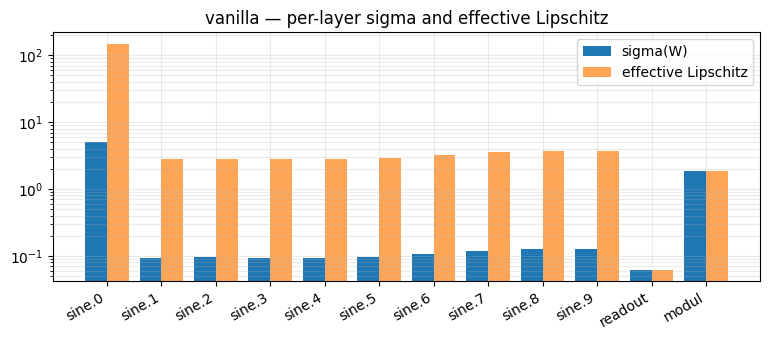

In [5]:
"""1.1 Weight-level spectral audit of the vanilla SIREN.

Report, per linear layer:
    sigma_pi   — power-iteration estimate from `diagnostics.layer_sigmas`
    sigma_svd  — exact via `torch.linalg.svdvals` (cross-check)
    freq*sigma — the coefficient that appears in the per-layer Lipschitz
                 factor for a sine layer
    cond       — sigma_max / sigma_min_nonzero
    comment    — hand-added per-layer tag

Relates to chat.md §"Experiment 2": does sine.0 end up much larger than
the rest? If yes, treating layer 0 the same way as deeper layers in any
regularizer is almost certainly wrong.
"""
def sigma_table(model, freq=SIREN_FREQ_DEFAULT, label="model"):
    if model is None:
        print(f"[{label}] model missing — skipping")
        return {}
    sigmas_pi = layer_sigmas(model, n_iter=50)
    rows = []

    # walk layers in the same order layer_sigmas emits
    name_to_weight = {}
    sine_idx = 0
    for m in model.modules():
        if isinstance(m, SineAffine):
            name_to_weight[f"sine.{sine_idx}"] = m.affine.weight
            sine_idx += 1
    siren = getattr(model, "siren", None)
    if siren is not None and hasattr(siren, "hidden2rgb"):
        name_to_weight["readout"] = siren.hidden2rgb.weight
    if hasattr(model, "modul"):
        name_to_weight["modul"] = model.modul.weight

    table = {}
    for name, sig_pi in sigmas_pi.items():
        W = name_to_weight[name]
        W2 = W.reshape(W.shape[0], -1)
        svals = torch.linalg.svdvals(W2).detach().cpu().numpy()
        sig_svd = float(svals[0])
        nz = svals[svals > 1e-10]
        cond = float(svals[0] / nz.min()) if len(nz) else float("inf")
        is_sine_hidden = name.startswith("sine.")
        effective = freq * sig_svd if is_sine_hidden else sig_svd
        if name == "sine.0":
            comment = "first layer (raw-coordinate input)"
        elif name == "readout":
            comment = "pure linear readout"
        elif name == "modul":
            comment = "phi -> per-layer shifts"
        else:
            comment = ""
        rows.append((name, sig_pi, sig_svd, effective, cond, comment))
        table[name] = {"sigma_pi": sig_pi, "sigma_svd": sig_svd,
                       "effective": effective, "cond": cond}

    print(f"\n[{label}] per-layer spectral audit (freq={freq})")
    print(f"{'layer':<10} {'sigma_pi':>10} {'sigma_svd':>10} {'freq*sigma':>12} {'cond':>10}  comment")
    print("-" * 76)
    for name, sp, ss, eff, cnd, cmt in rows:
        print(f"{name:<10} {sp:>10.4f} {ss:>10.4f} {eff:>12.3f} {cnd:>10.2f}  {cmt}")
    return table


VANILLA_SIGMAS = sigma_table(vanilla, label="vanilla")

# Small bar chart -- show sigma and freq*sigma on the same axes for sine layers.
if vanilla is not None:
    names = list(VANILLA_SIGMAS.keys())
    sig   = [VANILLA_SIGMAS[n]["sigma_svd"] for n in names]
    eff   = [VANILLA_SIGMAS[n]["effective"] for n in names]
    fig, ax = plt.subplots(figsize=(1.2 + 0.55 * len(names), 3.5))
    xs = np.arange(len(names))
    ax.bar(xs - 0.2, sig, width=0.4, label="sigma(W)")
    ax.bar(xs + 0.2, eff, width=0.4, label="effective Lipschitz", alpha=0.7)
    ax.set_xticks(xs); ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_yscale("log")
    ax.set_title("vanilla — per-layer sigma and effective Lipschitz")
    ax.legend(); ax.grid(True, which="both", alpha=0.25)
    plt.tight_layout(); plt.show()


[vanilla] activation summary (pre-sine wrap = range / 2pi; satur_pi = fraction of |pre| > pi)
layer      pre_min   pre_max   pre_std    wrap  satur_pi  post_std
--------------------------------------------------------------------
sine.0     -777.89    736.66    192.26  241.05     0.985     0.707
sine.1       -5.31      5.49      1.27    1.72     0.011     0.701
sine.2       -5.57      5.65      1.29    1.78     0.016     0.690
sine.3       -5.61      4.95      1.27    1.68     0.012     0.691
sine.4       -5.76      5.81      1.47    1.84     0.029     0.706
sine.5       -5.54      5.37      1.30    1.74     0.016     0.695
sine.6       -5.86      5.40      1.38    1.79     0.026     0.698
sine.7       -6.15      6.57      1.56    2.02     0.044     0.721
sine.8       -7.36      8.11      1.82    2.46     0.080     0.724
sine.9       -6.24      8.04      1.56    2.27     0.045     0.724


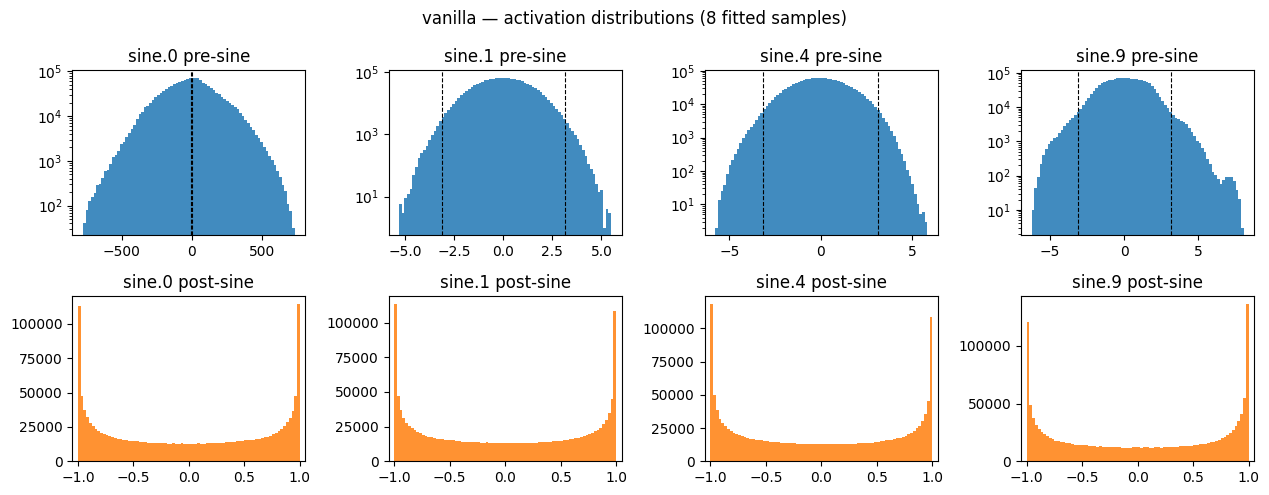

In [6]:
"""1.2 Pre- and post-sine activation distributions (vanilla).

For each of the N_DIAG_SAMPLES test images:
    - fit phi* from scratch for FIT_STEPS_SLOW iters (converged fit)
    - forward with hooks on every SinActivation
    - record per-layer pre-sine range, wrap index (pre-sine span / 2pi),
      saturation rate (fraction of |pre-sine| > pi), and post-sine range.

Key question from chat.md §4: is `sine.0` running far outside [-pi, pi]
because raw integer meshgrid coordinates * freq scale up large? If yes,
the first-layer *representation* is wrap-around-dominated — that's a
pretty strong hint that any regularizer on W_0 will fight convergence.
"""
def collect_activations(model, images, steps=FIT_STEPS_SLOW):
    """Returns a dict {layer_name: (B, N, features) tensor} stacked over B samples
    for both 'pre' and 'post' activations.
    """
    B = images.shape[0]
    per_sample = []
    for i in range(B):
        img_flat = images[i].flatten()
        phi, _ = fit_phi(model, img_flat, steps=steps)
        with hooked_forward(model) as buf:
            _ = model(phi)
        per_sample.append({k: v.clone() for k, v in buf.items()})
    # stack along dim 0 — each buf value is shape (N, hidden)
    out = {}
    for k in per_sample[0]:
        out[k] = torch.stack([s[k] for s in per_sample], dim=0)  # (B, N, hidden)
    return out


def summarize_activations(bufs):
    """Produce a per-layer summary table."""
    sine_layers = sorted(
        {k.split(".")[1] for k in bufs if k.startswith("sine.")},
        key=int,
    )
    rows = []
    for idx in sine_layers:
        pre  = bufs[f"sine.{idx}.pre"].flatten().cpu().numpy()
        post = bufs[f"sine.{idx}.post"].flatten().cpu().numpy()
        pre_abs = np.abs(pre)
        rows.append({
            "layer":      f"sine.{idx}",
            "pre_min":    float(pre.min()),
            "pre_max":    float(pre.max()),
            "pre_mean":   float(pre.mean()),
            "pre_std":    float(pre.std()),
            "wrap":       float(np.ptp(pre) / (2 * np.pi)),
            "satur_pi":   float((pre_abs > np.pi).mean()),
            "post_mean":  float(post.mean()),
            "post_std":   float(post.std()),
        })
    return rows


def print_activation_table(rows, label):
    print(f"\n[{label}] activation summary (pre-sine wrap = range / 2pi; satur_pi = fraction of |pre| > pi)")
    print(f"{'layer':<8} {'pre_min':>9} {'pre_max':>9} {'pre_std':>9} {'wrap':>7} {'satur_pi':>9} {'post_std':>9}")
    print("-" * 68)
    for r in rows:
        print(f"{r['layer']:<8} {r['pre_min']:>9.2f} {r['pre_max']:>9.2f} "
              f"{r['pre_std']:>9.2f} {r['wrap']:>7.2f} {r['satur_pi']:>9.3f} {r['post_std']:>9.3f}")


def plot_activation_grid(bufs, label, layer_idx_list=None):
    """Histogram of pre-sine and post-sine for a subset of layers."""
    sine_layers = sorted({k.split(".")[1] for k in bufs if k.startswith("sine.")}, key=int)
    if layer_idx_list is None:
        last = int(sine_layers[-1])
        layer_idx_list = [0, 1, max(1, last // 2), last]  # 0, 1, middle, last
    layer_idx_list = sorted(set(layer_idx_list))
    cols = len(layer_idx_list)
    fig, axes = plt.subplots(2, cols, figsize=(3.2 * cols, 5))
    if cols == 1:
        axes = np.array([[axes[0]], [axes[1]]])
    for j, idx in enumerate(layer_idx_list):
        pre  = bufs[f"sine.{idx}.pre"].flatten().cpu().numpy()
        post = bufs[f"sine.{idx}.post"].flatten().cpu().numpy()
        axes[0, j].hist(pre, bins=80, alpha=0.85)
        for x in (-np.pi, np.pi):
            axes[0, j].axvline(x, color="k", ls="--", lw=0.8)
        axes[0, j].set_title(f"sine.{idx} pre-sine")
        axes[0, j].set_yscale("log")
        axes[1, j].hist(post, bins=80, alpha=0.85, color="tab:orange")
        axes[1, j].set_title(f"sine.{idx} post-sine")
        axes[1, j].set_xlim(-1.05, 1.05)
    fig.suptitle(f"{label} — activation distributions ({N_DIAG_SAMPLES} fitted samples)")
    plt.tight_layout(); plt.show()


if vanilla is not None:
    VANILLA_ACTS  = collect_activations(vanilla, diag_images, steps=FIT_STEPS_SLOW)
    VANILLA_ASUMM = summarize_activations(VANILLA_ACTS)
    print_activation_table(VANILLA_ASUMM, "vanilla")
    plot_activation_grid(VANILLA_ACTS, "vanilla")

In [7]:
"""1.3 Coordinate-scale audit (vanilla).

The repo's ModulatedSIREN uses an unnormalized integer meshgrid:
    coord in {0, 1, ..., 27} x {0, 1, ..., 27}  (see SIREN.py:156-159)
so the first-layer pre-sine is
    z_0 = freq * (W_0 @ coord + b_0 + shift_0)
and an analytical upper bound on |z_0| is
    |z_0|_max <= freq * sigma(W_0) * ||coord||_2_max + freq * (|b_0| + |shift_0|).

This cell prints:
    - meshgrid range (should be 0..27 for 28x28 MNIST)
    - freq * sigma(W_0)
    - the analytical upper bound, compared against the empirical max
      pre-sine from §1.2. A tight match confirms the scale-meets-freq
      hypothesis from chat.md §"Case B".
"""
def coordinate_audit(model, acts_buf, label="model"):
    if model is None:
        print(f"[{label}] missing — skipping")
        return
    coord = model.meshgrid
    coord_max_norm = float(coord.norm(dim=1).max().item())
    print(f"[{label}] meshgrid: min={coord.min().item():.1f} max={coord.max().item():.1f} "
          f"shape={tuple(coord.shape)} ||coord||_2_max={coord_max_norm:.2f}")

    # sigma(W_0) via svd, and freq
    first_sine = next(m for m in model.modules() if isinstance(m, SineAffine))
    W0 = first_sine.affine.weight
    sig_W0 = float(torch.linalg.svdvals(W0).max().item())
    freq   = float(first_sine.freq)
    b0     = first_sine.affine.bias
    bmax   = float(b0.abs().max().item())

    bound_no_shift = freq * sig_W0 * coord_max_norm + freq * bmax
    print(f"[{label}] freq={freq:.1f}  sigma(W_0)={sig_W0:.3f}  |b_0|_max={bmax:.3f}")
    print(f"[{label}] analytical |z_0|_max upper bound (no shift) = {bound_no_shift:.2f}")

    if acts_buf is not None and "sine.0.pre" in acts_buf:
        pre0 = acts_buf["sine.0.pre"].cpu().numpy()
        emp_max = float(np.abs(pre0).max())
        wraps   = float(np.ptp(pre0) / (2 * np.pi))
        print(f"[{label}] empirical |z_0|_max = {emp_max:.2f}  (wraps ~ {wraps:.2f} sine periods)")
        print(f"[{label}] verdict: pre-sine wraps through ~{wraps:.1f} full periods at layer 0 "
              f"{'— scale is likely the dominant factor' if wraps > 3 else '— scale is modest'}")


if vanilla is not None:
    coordinate_audit(vanilla, VANILLA_ACTS, "vanilla")

[vanilla] meshgrid: min=0.0 max=27.0 shape=(784, 2) ||coord||_2_max=38.18
[vanilla] freq=30.0  sigma(W_0)=4.982  |b_0|_max=0.001
[vanilla] analytical |z_0|_max upper bound (no shift) = 5707.47
[vanilla] empirical |z_0|_max = 777.89  (wraps ~ 241.05 sine periods)
[vanilla] verdict: pre-sine wraps through ~241.0 full periods at layer 0 — scale is likely the dominant factor


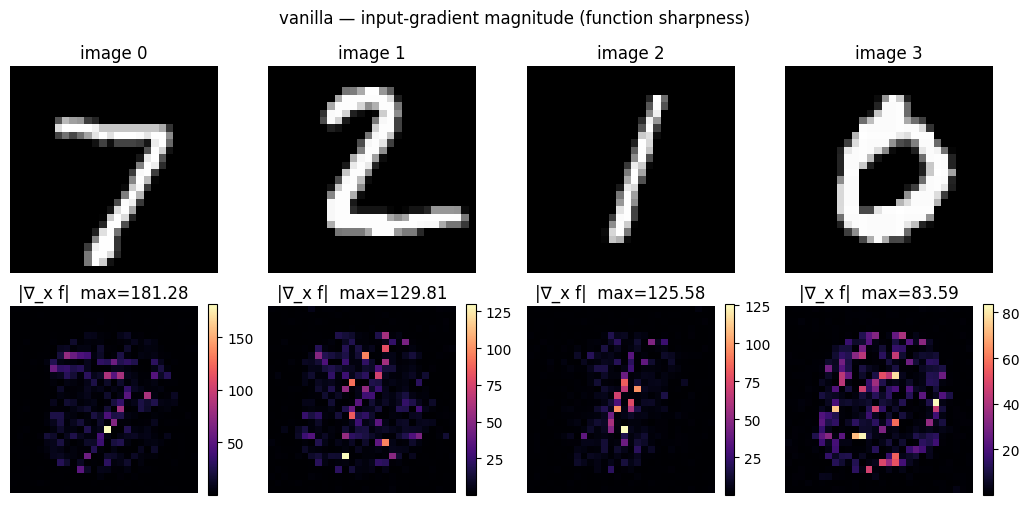


[vanilla] |grad_x f| stats over 4 samples  (mean / max / p99)
  sample 0: mean=5.280  max=181.281  p99=58.665
  sample 1: mean=5.115  max=129.812  p99=58.843
  sample 2: mean=3.410  max=125.585  p99=58.694
  sample 3: mean=4.835  max=83.587  p99=51.619


In [8]:
"""1.4 Function sharpness |grad_x f(x; phi*)| (vanilla).

For each diagnostic sample, freeze phi* (converged fit), then for every
output pixel compute the gradient of the scalar output with respect to
the continuous input coordinate and report its L2 norm. Gives both:
    - a scalar (mean / max) per sample
    - a per-pixel sharpness heatmap you can overlay on the reconstruction.

This is the `|grad_x f|` measurement from chat.md §"Experiment 3".
Unlike sigma(W), this measures the actual fitted function's slope; if
weights are bounded but the function is still sharp, the Lipschitz
constraint is not doing what you think.
"""
def input_gradient_norms(model, phi, coords=None):
    """For each of N coordinates, compute ||d f(x; phi) / dx||_2.
    Returns (N,) numpy array.
    """
    if coords is None:
        coords = model.meshgrid.detach().clone()
    x = coords.detach().clone().requires_grad_(True)  # (N, 2)
    # Temporarily swap in the differentiable coord; use the same batched path
    # as evaluate_reconstruction so the affines see the new x.
    siren = model.siren
    hidden, num_layers = siren.hidden_features, siren.num_layers
    shift_all = model.modul(phi.view(1, -1))  # (1, hidden * L)
    h = x
    for i in range(num_layers):
        layer = siren.net[i]
        lin = layer.affine(h)                            # (N, hidden)
        shift_i = shift_all[0, i * hidden:(i + 1) * hidden]
        h = torch.sin(layer.freq * (lin + shift_i.unsqueeze(0)))
    out = siren.hidden2rgb(h).squeeze(-1)                # (N,)
    grads = torch.autograd.grad(out.sum(), x, retain_graph=False)[0]  # (N, 2)
    return grads.detach().norm(dim=1).cpu().numpy()


def sharpness_report(model, images, label, n_panels=4, steps=FIT_STEPS_SLOW):
    if model is None:
        print(f"[{label}] missing — skipping")
        return None
    H, W = images.shape[-2:]
    stats = []
    n_panels = min(n_panels, images.shape[0])
    fig, axes = plt.subplots(2, n_panels, figsize=(2.6 * n_panels, 5.2))
    if n_panels == 1:
        axes = np.array([[axes[0]], [axes[1]]])
    for i in range(n_panels):
        phi, _ = fit_phi(model, images[i].flatten(), steps=steps)
        g = input_gradient_norms(model, phi)             # (N,)
        g_img = g.reshape(H, W)
        stats.append({"mean": float(g.mean()),
                      "max":  float(g.max()),
                      "p99":  float(np.percentile(g, 99))})
        axes[0, i].imshow(images[i].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[0, i].set_title(f"image {i}"); axes[0, i].axis("off")
        im = axes[1, i].imshow(g_img, cmap="magma")
        axes[1, i].set_title(f"|∇_x f|  max={g.max():.2f}")
        axes[1, i].axis("off")
        fig.colorbar(im, ax=axes[1, i], fraction=0.046)
    fig.suptitle(f"{label} — input-gradient magnitude (function sharpness)")
    plt.tight_layout(); plt.show()
    # aggregate
    print(f"\n[{label}] |grad_x f| stats over {n_panels} samples  (mean / max / p99)")
    for i, s in enumerate(stats):
        print(f"  sample {i}: mean={s['mean']:.3f}  max={s['max']:.3f}  p99={s['p99']:.3f}")
    return stats


VANILLA_SHARP = sharpness_report(vanilla, diag_images, "vanilla",
                                 n_panels=min(4, N_DIAG_SAMPLES))


[vanilla] fidelity curve over 64 images
 iters        MSE     PSNR     SSIM
     5 2.6216e-02    16.27    0.527
    20 2.0399e-02    17.35    0.582
    50 1.8009e-02    17.94    0.612
   100 1.6622e-02    18.33    0.631
   200 1.5570e-02    18.66    0.646


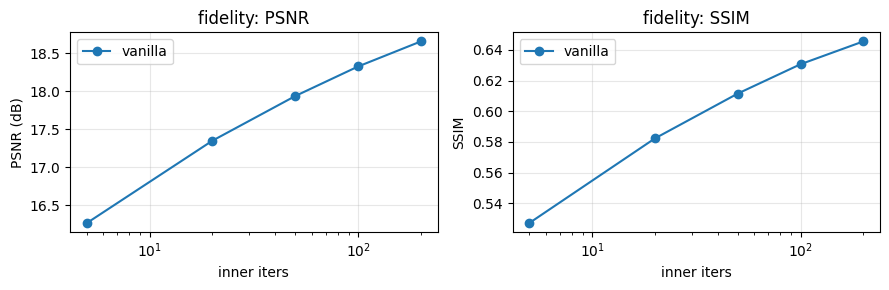

In [9]:
"""1.5 Reconstruction fidelity: PSNR / SSIM vs inner-loop iters (vanilla).

Re-fits N_FIDELITY_IMAGES test images from scratch and records metrics at
snapshot iterations. The `iters=5` row is apples-to-apples with what the
downstream classifier sees when makeset.py --iters 5 is used to build the
functaset.
"""
ITER_SNAPSHOTS = [5, 20, 50, 100, 200]


def fidelity_curve(model, images, snapshots=ITER_SNAPSHOTS, lr=FIT_LR, label="model"):
    """Returns {iters: {'mse_mean', 'psnr_mean', 'ssim_mean'}} plus raw lists."""
    if model is None:
        print(f"[{label}] missing — skipping")
        return None
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    B = images.shape[0]
    H, W = images.shape[-2:]
    tgt_flat = images.view(B, -1).unsqueeze(-1).to(DEVICE)    # (B, N, 1)
    tgt_2d   = images.clamp(0, 1).to(DEVICE)                  # (B, H, W)
    modul_features = model.modul_features
    phi = torch.zeros(B, modul_features, device=DEVICE, requires_grad=True)
    opt = optim.SGD([phi], lr=lr)
    max_step = max(snapshots)
    snap_set = set(snapshots)
    results = {}

    for step in range(1, max_step + 1):
        opt.zero_grad()
        fitted = batched_forward(model, phi)
        per_img = ((fitted - tgt_flat) ** 2).mean(dim=(1, 2))
        per_img.sum().backward()
        opt.step()
        if step in snap_set:
            with torch.no_grad():
                fitted_post = batched_forward(model, phi)
                f2d = fitted_post.squeeze(-1).view(B, H, W).clamp(0, 1)
                mse  = ((fitted_post - tgt_flat) ** 2).mean(dim=(1, 2))
                psnr = 10 * torch.log10(1.0 / torch.clamp(mse, min=1e-12))
                ssim = ssim_2d_batch(f2d, tgt_2d)
                results[step] = {
                    "mse_mean":  float(mse.mean().item()),
                    "psnr_mean": float(psnr.mean().item()),
                    "ssim_mean": float(ssim.mean().item()),
                }
    print(f"\n[{label}] fidelity curve over {B} images")
    print(f"{'iters':>6} {'MSE':>10} {'PSNR':>8} {'SSIM':>8}")
    for s in snapshots:
        r = results[s]
        print(f"{s:>6} {r['mse_mean']:>10.4e} {r['psnr_mean']:>8.2f} {r['ssim_mean']:>8.3f}")
    return results


VANILLA_FIDELITY = fidelity_curve(vanilla, mnist_images, label="vanilla")

if VANILLA_FIDELITY is not None:
    xs = list(VANILLA_FIDELITY.keys())
    psnr = [VANILLA_FIDELITY[s]["psnr_mean"] for s in xs]
    ssim = [VANILLA_FIDELITY[s]["ssim_mean"] for s in xs]
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    axes[0].plot(xs, psnr, "o-", label="vanilla"); axes[0].set_xscale("log")
    axes[0].set_xlabel("inner iters"); axes[0].set_ylabel("PSNR (dB)")
    axes[0].set_title("fidelity: PSNR"); axes[0].grid(alpha=0.3)
    axes[1].plot(xs, ssim, "o-", label="vanilla"); axes[1].set_xscale("log")
    axes[1].set_xlabel("inner iters"); axes[1].set_ylabel("SSIM")
    axes[1].set_title("fidelity: SSIM"); axes[1].grid(alpha=0.3)
    for a in axes: a.legend()
    plt.tight_layout(); plt.show()

## 2. Soft-Lipschitz diagnostics

Same battery of tests, framed as a direct comparison against vanilla. Adds one cell that overlays the per-layer spectral-norm caps and tags each layer as "bit the constraint" or "never activated".


[softlip] per-layer spectral audit (freq=30.0)
layer        sigma_pi  sigma_svd   freq*sigma       cond  comment
----------------------------------------------------------------------------
sine.0         4.9823     4.9823      149.468       1.11  first layer (raw-coordinate input)
sine.1         0.0939     0.0942        2.827    4755.26  
sine.2         0.0963     0.0966        2.897     992.00  
sine.3         0.0945     0.0946        2.839    1225.47  
sine.4         0.0951     0.0951        2.853    9726.93  
sine.5         0.0991     0.0991        2.973    3012.41  
sine.6         0.1199     0.1199        3.598   18826.43  
sine.7         0.1764     0.1764        5.293    4516.14  
sine.8         0.1843     0.1844        5.531     971.93  
sine.9         0.2096     0.2096        6.288    1460.60  
readout        0.0768     0.0768        0.077       1.00  pure linear readout
modul          1.6599     1.6763        1.676       2.31  phi -> per-layer shifts

[softlip] cap map  L=30 

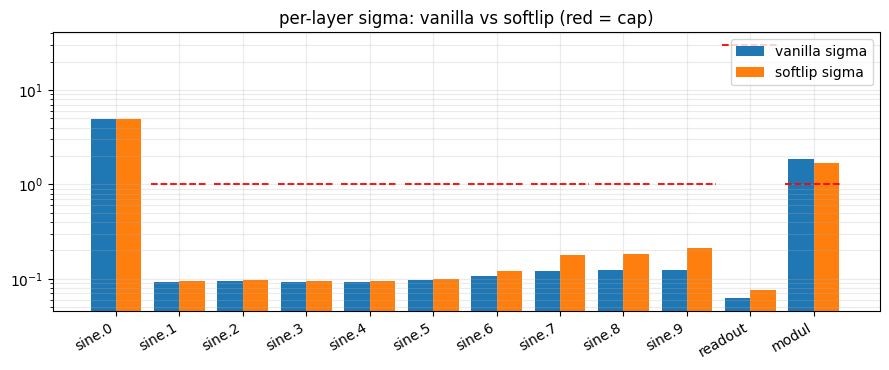

In [10]:
"""2.1 Sigma table for softlip with per-layer caps overlaid.

Derives caps from the checkpoint's `variant_args` (falling back to the
§0 defaults). Cap formula matches variants/soft_lipschitz.py::_collect_layers:
    sine.*  -> L / freq
    readout -> L
    modul   -> L / freq   (only if apply_to == 'all')

For each layer, tags:
    BIT   : sigma >= 0.9 * cap   (constraint was active)
    NEAR  : 0.5 * cap <= sigma < 0.9 * cap
    IDLE  : sigma < 0.5 * cap   (cap never bit, penalty contributed 0)
"""
def softlip_caps(meta, freq=SIREN_FREQ_DEFAULT,
                 L_default=SOFTLIP_L_DEFAULT,
                 apply_default=SOFTLIP_APPLY_TO_DEFAULT,
                 skip_default=SOFTLIP_SKIP_FIRST_DEFAULT):
    va = (meta or {}).get("variant_args", {}) or {}
    L          = float(va.get("soft_lip_cap",         L_default))
    apply_to   =       va.get("soft_lip_apply_to",    apply_default)
    skip_first = bool( va.get("soft_lip_skip_first",  skip_default))
    return {"L": L, "apply_to": apply_to, "skip_first": skip_first, "freq": freq}


def sigma_vs_cap_table(model, caps, label="softlip"):
    if model is None:
        print(f"[{label}] missing — skipping")
        return {}
    sigmas = sigma_table(model, freq=caps["freq"], label=label)  # prints its own table
    L, apply_to, skip_first, freq = caps["L"], caps["apply_to"], caps["skip_first"], caps["freq"]

    print(f"\n[{label}] cap map  L={L:g}  apply_to='{apply_to}'  skip_first={skip_first}")
    print(f"{'layer':<10} {'sigma':>10} {'cap':>10} {'ratio':>8}  status")
    print("-" * 54)
    per_layer_caps = {}
    for name, info in sigmas.items():
        sig = info["sigma_svd"]
        if name.startswith("sine."):
            idx = int(name.split(".")[1])
            if skip_first and idx == 0:
                per_layer_caps[name] = None
                print(f"{name:<10} {sig:>10.3f}       —    —     EXCLUDED")
                continue
            cap = L / freq
        elif name == "readout":
            if apply_to not in ("sine_and_readout", "all"):
                per_layer_caps[name] = None
                print(f"{name:<10} {sig:>10.3f}       —    —     not penalized")
                continue
            cap = L
        elif name == "modul":
            if apply_to != "all":
                per_layer_caps[name] = None
                print(f"{name:<10} {sig:>10.3f}       —    —     not penalized")
                continue
            cap = L / freq
        else:
            per_layer_caps[name] = None
            continue
        per_layer_caps[name] = cap
        ratio = sig / cap if cap > 0 else float("inf")
        if ratio >= 0.9:    status = "BIT   (constraint active)"
        elif ratio >= 0.5:  status = "NEAR  (approaching cap)"
        else:               status = "IDLE  (penalty = 0)"
        print(f"{name:<10} {sig:>10.3f} {cap:>10.3f} {ratio:>8.2f}  {status}")
    return {"sigmas": sigmas, "caps": per_layer_caps, "meta": caps}


SOFTLIP_CAPS = softlip_caps(softlip_meta) if softlip is not None else None
SOFTLIP_SIGMA_REPORT = sigma_vs_cap_table(softlip, SOFTLIP_CAPS) if softlip is not None else None

# Overlay bar chart: vanilla sigma vs softlip sigma, with cap lines
if softlip is not None and vanilla is not None:
    names = [n for n in SOFTLIP_SIGMA_REPORT["sigmas"] if n in VANILLA_SIGMAS]
    sv = [VANILLA_SIGMAS[n]["sigma_svd"]             for n in names]
    ss = [SOFTLIP_SIGMA_REPORT["sigmas"][n]["sigma_svd"] for n in names]
    cs = [SOFTLIP_SIGMA_REPORT["caps"][n]            for n in names]
    fig, ax = plt.subplots(figsize=(1.2 + 0.65 * len(names), 3.8))
    xs = np.arange(len(names))
    ax.bar(xs - 0.2, sv, width=0.4, label="vanilla sigma")
    ax.bar(xs + 0.2, ss, width=0.4, label="softlip sigma")
    for i, c in enumerate(cs):
        if c is not None:
            ax.hlines(c, i - 0.45, i + 0.45, colors="red", ls="--", lw=1.3,
                      label="cap" if i == 0 else None)
    ax.set_xticks(xs); ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_yscale("log"); ax.set_title("per-layer sigma: vanilla vs softlip (red = cap)")
    ax.legend(); ax.grid(True, which="both", alpha=0.25)
    plt.tight_layout(); plt.show()


[softlip] activation summary (pre-sine wrap = range / 2pi; satur_pi = fraction of |pre| > pi)
layer      pre_min   pre_max   pre_std    wrap  satur_pi  post_std
--------------------------------------------------------------------
sine.0     -777.86    736.47    192.27  241.01     0.985     0.707
sine.1       -5.56      5.62      1.29    1.78     0.013     0.702
sine.2       -5.59      5.79      1.32    1.81     0.021     0.684
sine.3       -5.53      6.01      1.29    1.84     0.015     0.690
sine.4       -6.56      6.10      1.56    2.02     0.040     0.707
sine.5       -5.71      5.72      1.41    1.82     0.021     0.711
sine.6       -6.48      6.86      1.59    2.12     0.049     0.717
sine.7      -10.27      9.64      2.50    3.17     0.210     0.716
sine.8       -9.73      8.84      2.20    2.96     0.159     0.705
sine.9       -8.99      9.70      1.77    2.97     0.068     0.722


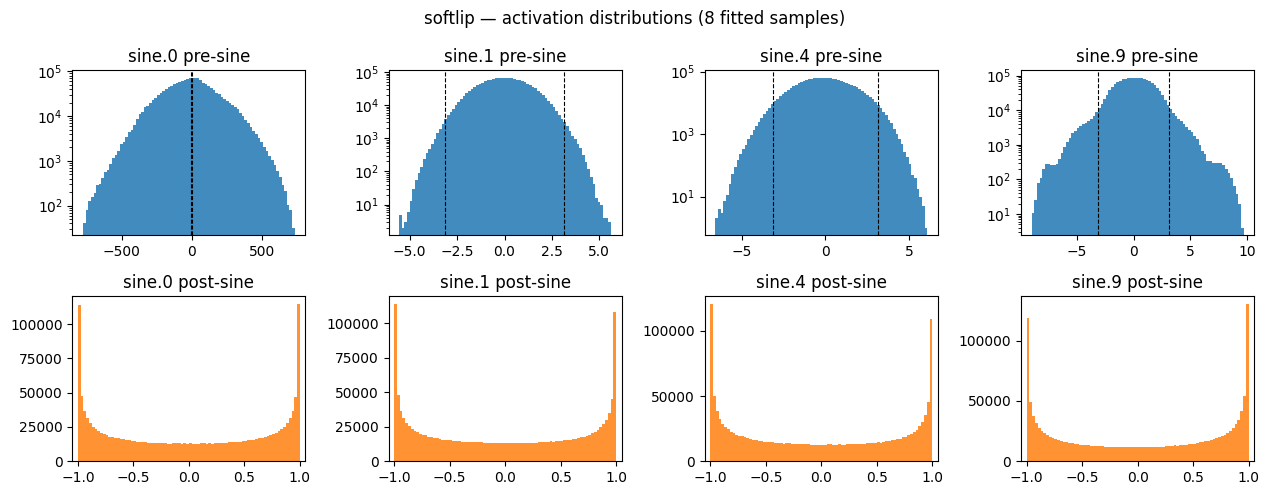

[softlip] meshgrid: min=0.0 max=27.0 shape=(784, 2) ||coord||_2_max=38.18
[softlip] freq=30.0  sigma(W_0)=4.982  |b_0|_max=0.001
[softlip] analytical |z_0|_max upper bound (no shift) = 5707.26
[softlip] empirical |z_0|_max = 777.86  (wraps ~ 241.01 sine periods)
[softlip] verdict: pre-sine wraps through ~241.0 full periods at layer 0 — scale is likely the dominant factor


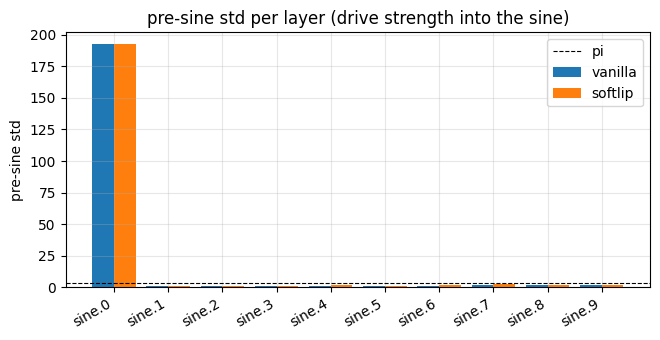

In [11]:
"""2.2 Softlip activation distributions + coordinate audit + overlay on vanilla.

Runs the same hook collection on the softlip backbone, prints the
summary table, and overlays per-layer pre-sine std (std is a good
one-number summary of "how hard the sine is being driven") on top of
vanilla. Also repeats the coordinate audit so we can see whether the
soft-Lipschitz constraint brought |z_0| back into [-pi, pi].
"""
if softlip is not None:
    SOFTLIP_ACTS  = collect_activations(softlip, diag_images, steps=FIT_STEPS_SLOW)
    SOFTLIP_ASUMM = summarize_activations(SOFTLIP_ACTS)
    print_activation_table(SOFTLIP_ASUMM, "softlip")
    plot_activation_grid(SOFTLIP_ACTS, "softlip")
    coordinate_audit(softlip, SOFTLIP_ACTS, "softlip")

    # overlay: per-layer pre-sine std
    if vanilla is not None:
        layers = [r["layer"] for r in VANILLA_ASUMM]
        v_std  = [r["pre_std"] for r in VANILLA_ASUMM]
        s_std  = [r["pre_std"] for r in SOFTLIP_ASUMM]
        xs = np.arange(len(layers))
        fig, ax = plt.subplots(figsize=(1.2 + 0.55 * len(layers), 3.5))
        ax.bar(xs - 0.2, v_std, width=0.4, label="vanilla")
        ax.bar(xs + 0.2, s_std, width=0.4, label="softlip")
        ax.axhline(np.pi, color="k", ls="--", lw=0.8, label="pi")
        ax.set_xticks(xs); ax.set_xticklabels(layers, rotation=30, ha="right")
        ax.set_ylabel("pre-sine std")
        ax.set_title("pre-sine std per layer (drive strength into the sine)")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()
else:
    SOFTLIP_ACTS, SOFTLIP_ASUMM = None, None
    print("[softlip] missing — §2.2 skipped")

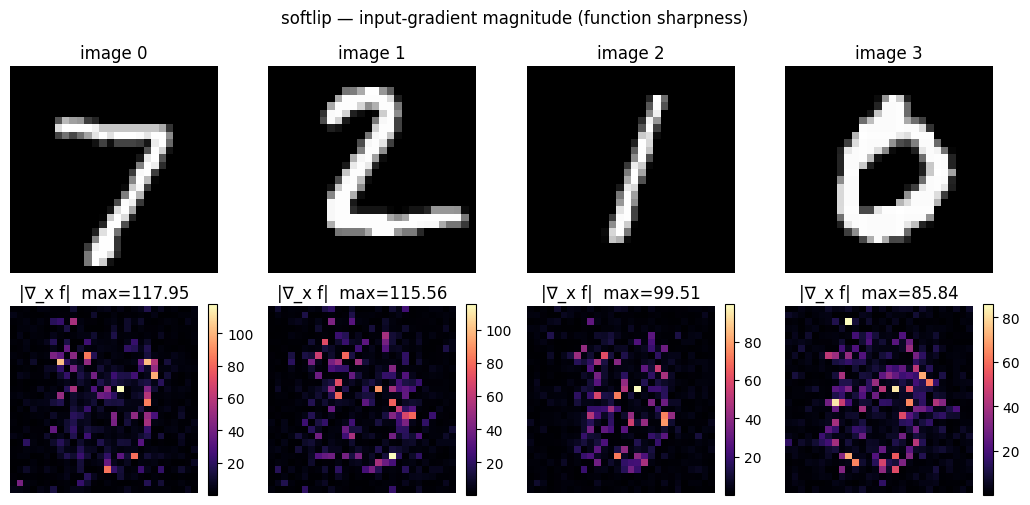


[softlip] |grad_x f| stats over 4 samples  (mean / max / p99)
  sample 0: mean=6.775  max=117.947  p99=62.646
  sample 1: mean=7.052  max=115.563  p99=68.123
  sample 2: mean=5.558  max=99.509  p99=54.274
  sample 3: mean=6.534  max=85.842  p99=56.529


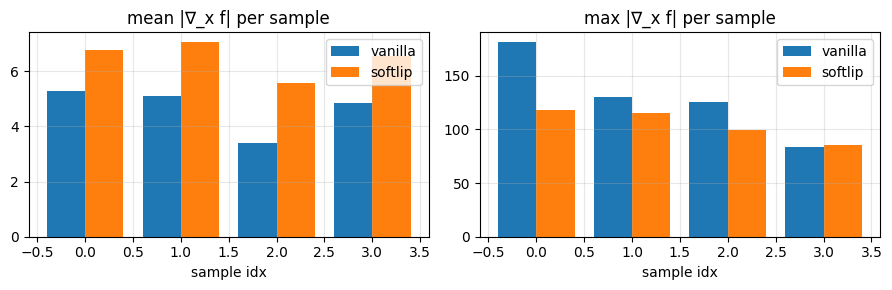

In [12]:
"""2.3 Softlip function sharpness + |grad_x f| overlay vs vanilla."""
if softlip is not None:
    SOFTLIP_SHARP = sharpness_report(softlip, diag_images, "softlip",
                                     n_panels=min(4, N_DIAG_SAMPLES))
    if vanilla is not None and VANILLA_SHARP is not None:
        v_max = [s["max"]  for s in VANILLA_SHARP]
        s_max = [s["max"]  for s in SOFTLIP_SHARP]
        v_mean = [s["mean"] for s in VANILLA_SHARP]
        s_mean = [s["mean"] for s in SOFTLIP_SHARP]
        xs = np.arange(len(VANILLA_SHARP))
        fig, axes = plt.subplots(1, 2, figsize=(9, 3))
        axes[0].bar(xs - 0.2, v_mean, width=0.4, label="vanilla")
        axes[0].bar(xs + 0.2, s_mean, width=0.4, label="softlip")
        axes[0].set_title("mean |∇_x f| per sample"); axes[0].set_xlabel("sample idx")
        axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].bar(xs - 0.2, v_max, width=0.4, label="vanilla")
        axes[1].bar(xs + 0.2, s_max, width=0.4, label="softlip")
        axes[1].set_title("max |∇_x f| per sample"); axes[1].set_xlabel("sample idx")
        axes[1].legend(); axes[1].grid(alpha=0.3)
        plt.tight_layout(); plt.show()
else:
    SOFTLIP_SHARP = None
    print("[softlip] missing — §2.3 skipped")


[softlip] fidelity curve over 64 images
 iters        MSE     PSNR     SSIM
     5 3.7430e-02    14.49    0.415
    20 2.8056e-02    15.75    0.478
    50 2.3780e-02    16.44    0.497
   100 2.0802e-02    17.03    0.507
   200 1.9407e-02    17.56    0.508


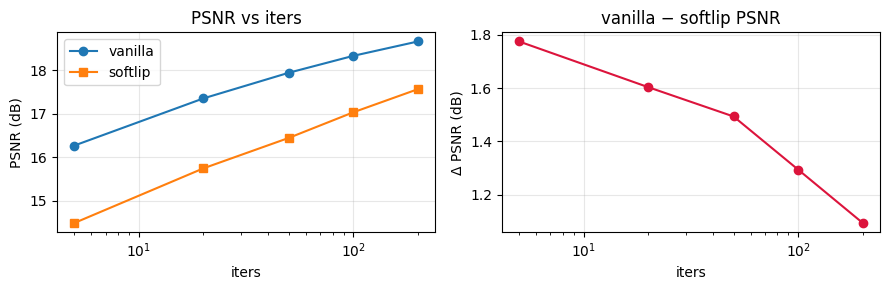

In [13]:
"""2.4 Reconstruction gap: softlip vs vanilla fidelity curve.

Runs fidelity_curve on softlip and overlays it with the vanilla one from
§1.5. Should reproduce the flat ~4 dB PSNR gap from context/report.md §3.1
if the current softlip checkpoint is the same one used for that report.
"""
if softlip is not None:
    SOFTLIP_FIDELITY = fidelity_curve(softlip, mnist_images, label="softlip")
else:
    SOFTLIP_FIDELITY = None

if SOFTLIP_FIDELITY is not None and VANILLA_FIDELITY is not None:
    xs = list(VANILLA_FIDELITY.keys())
    vp = [VANILLA_FIDELITY[s]["psnr_mean"] for s in xs]
    sp = [SOFTLIP_FIDELITY[s]["psnr_mean"] for s in xs]
    gap = [a - b for a, b in zip(vp, sp)]
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    axes[0].plot(xs, vp, "o-", label="vanilla")
    axes[0].plot(xs, sp, "s-", label="softlip")
    axes[0].set_xscale("log"); axes[0].set_xlabel("iters"); axes[0].set_ylabel("PSNR (dB)")
    axes[0].set_title("PSNR vs iters"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(xs, gap, "o-", color="crimson")
    axes[1].set_xscale("log"); axes[1].set_xlabel("iters"); axes[1].set_ylabel("Δ PSNR (dB)")
    axes[1].set_title("vanilla − softlip PSNR"); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 3. Perturbation & boundary study

How does each model react to small perturbations of the *input image*? Three complementary probes:

- **3.1 Random-noise sensitivity.** Cheap. Adds uniform noise of bounded $\|\delta\|_\infty \le \varepsilon$, refits $\varphi^*(x+\delta)$, measures how much $\varphi^*$, the reconstruction, and the classifier logits move. Produces a "representation-shift curve".
- **3.2 Adversarial trajectory.** Runs a short PGD (unrolled via the standard full-PGD pattern) on a handful of images and records per-step margin, perturbation magnitude, and $\varphi$ shift.
- **3.3 2D decision-boundary slice.** Grid of $\varphi^*$ refits around a clean anchor, along two orthogonal directions (adversarial + random). Produces the classical decision-boundary plot.

§3.1 runs always. §3.2 and §3.3 are guarded by `RUN_HEAVY` in §0.2 — flip it to `True` and re-run those two cells.

[vanilla] missing model or classifier — skipping

[softlip] random perturbation sensitivity (16 samples, steps=5)
 eps*255     ||Δφ||     ||Δf||   ||Δlogit||    flip
    0.00      0.000      0.000        0.000   0.000
    2.00      0.001      0.106        0.131   0.000
    4.00      0.001      0.162        0.209   0.000
    8.00      0.002      0.240        0.364   0.000
   16.00      0.003      0.402        0.773   0.000
   32.00      0.006      0.739        1.792   0.000


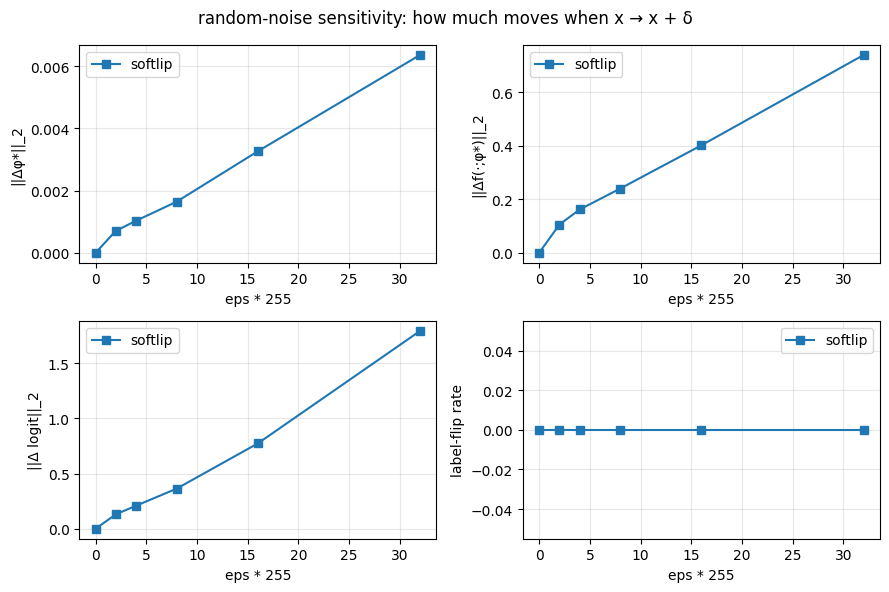

In [14]:
"""3.1 Random-noise sensitivity curves.

For each (model, classifier) pair and each epsilon in EPS_GRID:
    - sample N_PERT_SAMPLES clean images from the fidelity slice,
    - compute phi_clean = fit_phi(x, k=FIT_STEPS_FAST),
    - for each epsilon draw delta ~ Uniform(-eps, eps) of shape (28, 28),
    - compute phi_pert  = fit_phi(x+delta, k=FIT_STEPS_FAST) (same warm-start semantics as makeset, i.e. zero init),
    - record:
        phi_shift  = ||phi_pert - phi_clean||_2
        recon_shift= ||f(phi_pert) - f(phi_clean)||_2
        logit_shift= ||g(phi_pert) - g(phi_clean)||_2
        flip       = argmax(g(phi_pert)) != argmax(g(phi_clean))
Plots: four curves vs epsilon, both models overlaid.
"""
EPS_GRID = [0.0, 2/255, 4/255, 8/255, 16/255, 32/255]


def sensitivity_curve(model, clf, images, eps_grid=EPS_GRID,
                      n_samples=N_PERT_SAMPLES, steps=FIT_STEPS_FAST, seed=SEED,
                      label="model"):
    if model is None or clf is None:
        print(f"[{label}] missing model or classifier — skipping")
        return None
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    imgs = images[:n_samples].clamp(0, 1)
    B = imgs.shape[0]
    imgs_flat = imgs.view(B, -1)

    phi_clean, _ = batched_fit_phi(model, imgs_flat, steps=steps)
    with torch.no_grad():
        logits_clean = clf(phi_clean)
        pred_clean   = logits_clean.argmax(dim=1)
        recon_clean  = batched_forward(model, phi_clean).squeeze(-1)  # (B, N)

    rows = []
    for eps in eps_grid:
        if eps == 0:
            rows.append({"eps": 0.0, "phi_shift": 0.0, "recon_shift": 0.0,
                         "logit_shift": 0.0, "flip_rate": 0.0})
            continue
        delta = (torch.rand(imgs.shape, generator=gen, device=DEVICE) * 2 - 1) * eps
        x_pert = (imgs + delta).clamp(0, 1).view(B, -1)
        phi_pert, _ = batched_fit_phi(model, x_pert, steps=steps)
        with torch.no_grad():
            logits_pert = clf(phi_pert)
            recon_pert  = batched_forward(model, phi_pert).squeeze(-1)
            phi_shift   = (phi_pert - phi_clean).norm(dim=1).mean().item()
            recon_shift = (recon_pert - recon_clean).norm(dim=1).mean().item()
            logit_shift = (logits_pert - logits_clean).norm(dim=1).mean().item()
            flip_rate   = (logits_pert.argmax(dim=1) != pred_clean).float().mean().item()
        rows.append({"eps": eps, "phi_shift": phi_shift, "recon_shift": recon_shift,
                     "logit_shift": logit_shift, "flip_rate": flip_rate})

    print(f"\n[{label}] random perturbation sensitivity ({n_samples} samples, steps={steps})")
    print(f"{'eps*255':>8} {'||Δφ||':>10} {'||Δf||':>10} {'||Δlogit||':>12} {'flip':>7}")
    for r in rows:
        print(f"{r['eps']*255:>8.2f} {r['phi_shift']:>10.3f} {r['recon_shift']:>10.3f} "
              f"{r['logit_shift']:>12.3f} {r['flip_rate']:>7.3f}")
    return rows


VANILLA_SENS = sensitivity_curve(vanilla, vanilla_clf, mnist_images, label="vanilla")
SOFTLIP_SENS = sensitivity_curve(softlip, softlip_clf, mnist_images, label="softlip")

if VANILLA_SENS is not None or SOFTLIP_SENS is not None:
    fig, axes = plt.subplots(2, 2, figsize=(9, 6))
    keys   = [("phi_shift",  "||Δφ*||_2"),
              ("recon_shift","||Δf(·;φ*)||_2"),
              ("logit_shift","||Δ logit||_2"),
              ("flip_rate",  "label-flip rate")]
    ax = axes.flatten()
    for i, (k, ylabel) in enumerate(keys):
        if VANILLA_SENS is not None:
            xs = [r["eps"] * 255 for r in VANILLA_SENS]
            ys = [r[k]            for r in VANILLA_SENS]
            ax[i].plot(xs, ys, "o-", label="vanilla")
        if SOFTLIP_SENS is not None:
            xs = [r["eps"] * 255 for r in SOFTLIP_SENS]
            ys = [r[k]            for r in SOFTLIP_SENS]
            ax[i].plot(xs, ys, "s-", label="softlip")
        ax[i].set_xlabel("eps * 255"); ax[i].set_ylabel(ylabel)
        ax[i].grid(alpha=0.3); ax[i].legend()
    fig.suptitle("random-noise sensitivity: how much moves when x → x + δ")
    plt.tight_layout(); plt.show()

[3.2] vanilla missing — skipping
[3.2] softlip sample 0 (true=7, clean_pred=7): final pred=7  margin=0.000  phi_shift=0.01
[3.2] softlip sample 1 (true=2, clean_pred=2): final pred=2  margin=0.000  phi_shift=0.03
[3.2] softlip sample 2 (true=1, clean_pred=1): final pred=1  margin=0.000  phi_shift=0.01
[3.2] softlip sample 3 (true=0, clean_pred=0): final pred=0  margin=0.000  phi_shift=0.01


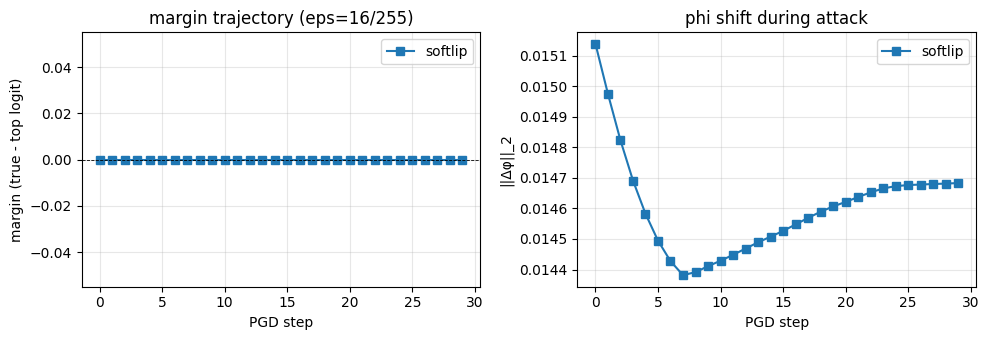

In [15]:
"""3.2 PGD trajectory telemetry.

Simplified per-sample unrolled PGD that records per-step metrics for
plotting. For each sample x:
    - compute clean phi* via N inner SGD steps (no grad w.r.t. x)
    - for each PGD step t:
         * clip perturbation to [-eps, eps]
         * refit phi from clean_mod by MOD_STEPS *differentiable* inner
           SGD steps (classic full-PGD pattern: unroll the inner loop)
         * compute classifier logits, take 1 - CE(logits, y) loss
         * step the PGD Adam optimizer
         * log ||delta||_inf, ||phi - phi_clean||_2, margin(y), pred_top

The loss sign matches attacks/full_pgd.py (`loss = 1 - CE`, we *minimize*
loss to maximize CE, i.e. misclassify). We reuse FullPGD.fit_image's
logic but simplified and with telemetry. Heavy; RUN_HEAVY gated.
"""
PGD_EPS       = 16 / 255
PGD_STEPS     = 30
PGD_LR        = 0.01
PGD_MOD_STEPS = 5
PGD_INNER_LR  = 0.01


def pgd_trajectory(model, clf, image, label, eps=PGD_EPS,
                   pgd_steps=PGD_STEPS, pgd_lr=PGD_LR,
                   mod_steps=PGD_MOD_STEPS, inner_lr=PGD_INNER_LR):
    """Run unrolled PGD on a single image and return per-step telemetry."""
    model = model.to(DEVICE).eval()
    clf   = clf.to(DEVICE).eval()
    for p in model.parameters(): p.requires_grad_(False)
    for p in clf.parameters():   p.requires_grad_(False)

    H, W = image.shape[-2:]
    x = image.to(DEVICE).float().view(H, W)
    y = torch.tensor([int(label)], device=DEVICE)

    # clean phi* with standalone SGD (no grad tracking)
    phi_clean, _ = fit_phi(model, x.flatten(), steps=mod_steps * 2, lr=inner_lr)
    with torch.no_grad():
        logits_clean = clf(phi_clean.view(1, -1))
        pred_clean   = int(logits_clean.argmax(dim=1).item())

    pert = torch.zeros(H, W, device=DEVICE, requires_grad=True)
    pgd_opt = optim.Adam([pert], lr=pgd_lr)
    ce = nn.CrossEntropyLoss()
    traj = []

    for t in range(pgd_steps):
        pgd_opt.zero_grad()
        proj = torch.clamp(pert, -eps, eps)
        x_pert = (x + proj).clamp(0, 1).view(-1, 1)

        # Differentiable inner loop (manual SGD, no higher dep needed)
        phi = phi_clean.detach().clone().requires_grad_(True)
        for _ in range(mod_steps):
            fitted = model(phi)
            inner_loss = ((fitted - x_pert) ** 2).mean()
            g, = torch.autograd.grad(inner_loss, phi, create_graph=True)
            phi = phi - inner_lr * g

        logits = clf(phi.view(1, -1))
        loss = 1 - ce(logits, y)
        loss.backward()
        pgd_opt.step()

        with torch.no_grad():
            proj_now   = torch.clamp(pert, -eps, eps).detach()
            d_inf      = float(proj_now.abs().max().item())
            top_logit  = float(logits.max().item())
            true_logit = float(logits[0, int(y.item())].item())
            margin     = true_logit - top_logit  # <= 0; 0 means true still argmax
            pred       = int(logits.argmax(dim=1).item())
            phi_shift  = float((phi.detach() - phi_clean).norm().item())
        traj.append({"step": t, "delta_inf": d_inf, "phi_shift": phi_shift,
                     "true_logit": true_logit, "top_logit": top_logit,
                     "margin": margin, "pred": pred})

    with torch.no_grad():
        x_final = (x + torch.clamp(pert, -eps, eps)).clamp(0, 1)
        delta_final = (x_final - x).detach()
    return {"pred_clean": pred_clean, "true": int(y.item()),
            "traj": traj, "delta": delta_final.cpu().numpy(),
            "x_clean": x.cpu().numpy(), "x_pert": x_final.cpu().numpy()}


PGD_RESULTS = {"vanilla": [], "softlip": []}

if RUN_HEAVY:
    for name, (m, c) in [("vanilla", (vanilla, vanilla_clf)),
                         ("softlip", (softlip, softlip_clf))]:
        if m is None or c is None:
            print(f"[3.2] {name} missing — skipping")
            continue
        for i in range(min(N_PGD_SAMPLES, diag_images.shape[0])):
            r = pgd_trajectory(m, c, diag_images[i], int(diag_labels[i].item()))
            PGD_RESULTS[name].append(r)
            final = r["traj"][-1]
            print(f"[3.2] {name} sample {i} (true={r['true']}, clean_pred={r['pred_clean']}): "
                  f"final pred={final['pred']}  margin={final['margin']:.3f}  "
                  f"phi_shift={final['phi_shift']:.2f}")
else:
    print("[3.2] RUN_HEAVY=False — set True in §0.2 and re-run to generate PGD telemetry")

# ---- plotting -----------------------------------------------------------
if PGD_RESULTS["vanilla"] or PGD_RESULTS["softlip"]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for name, style in [("vanilla", "o-"), ("softlip", "s-")]:
        if not PGD_RESULTS[name]:
            continue
        all_margin = np.stack([[t["margin"]    for t in r["traj"]] for r in PGD_RESULTS[name]])
        all_shift  = np.stack([[t["phi_shift"] for t in r["traj"]] for r in PGD_RESULTS[name]])
        steps = np.arange(all_margin.shape[1])
        axes[0].plot(steps, all_margin.mean(axis=0), style, label=name)
        axes[0].fill_between(steps,
                             all_margin.mean(axis=0) - all_margin.std(axis=0),
                             all_margin.mean(axis=0) + all_margin.std(axis=0), alpha=0.15)
        axes[1].plot(steps, all_shift.mean(axis=0), style, label=name)
    axes[0].axhline(0, color="k", ls="--", lw=0.6)
    axes[0].set_xlabel("PGD step"); axes[0].set_ylabel("margin (true - top logit)")
    axes[0].set_title(f"margin trajectory (eps={PGD_EPS*255:.0f}/255)")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_xlabel("PGD step"); axes[1].set_ylabel("||Δφ||_2")
    axes[1].set_title("phi shift during attack")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # Show final delta for sample 0 on both models
    if PGD_RESULTS["vanilla"] and PGD_RESULTS["softlip"]:
        fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
        for row, name in enumerate(["vanilla", "softlip"]):
            r = PGD_RESULTS[name][0]
            axes[row, 0].imshow(r["x_clean"], cmap="gray", vmin=0, vmax=1)
            axes[row, 0].set_title(f"{name}: clean")
            axes[row, 1].imshow(r["delta"],   cmap="RdBu", vmin=-PGD_EPS, vmax=PGD_EPS)
            axes[row, 1].set_title(f"δ* (±{PGD_EPS:.3f})")
            axes[row, 2].imshow(r["x_pert"],  cmap="gray", vmin=0, vmax=1)
            axes[row, 2].set_title("x + δ*")
            for a in axes[row]: a.axis("off")
        plt.tight_layout(); plt.show()

[vanilla] missing model or classifier — skipping


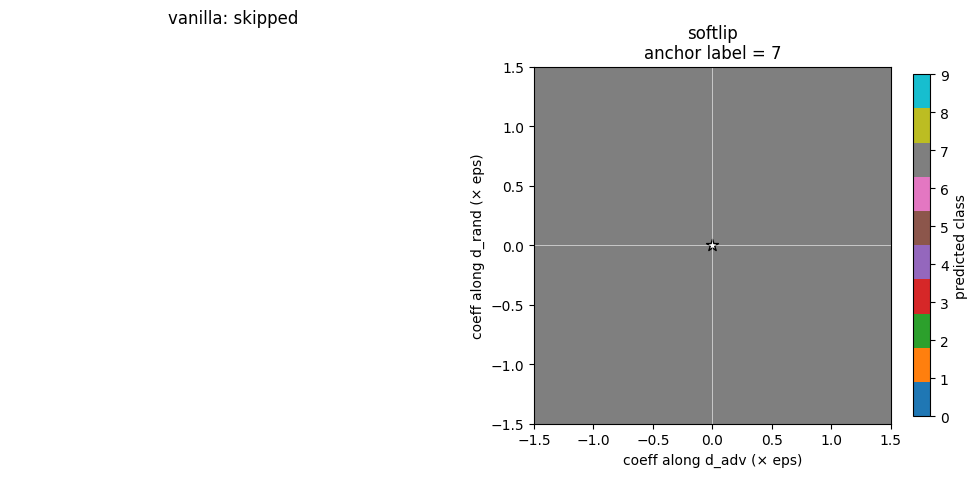

[3.3] softlip: fraction of slice still classified as 7 = 1.000


In [16]:
"""3.3 2D decision-boundary slice.

For an anchor image x0:
    1. build two orthonormal directions in input space:
         d_adv  = δ* from §3.2 (model-specific; uses that model's own
                  attack direction for its own slice)
         d_rand = random Gaussian orthogonalized to d_adv via Gram-Schmidt
    2. evaluate classifier on the grid
         x(a, b) = clip(x0 + a * eps * d_adv + b * eps * d_rand, 0, 1)
       for (a, b) in [-BOUNDARY_RANGE, BOUNDARY_RANGE] with N_BOUNDARY_GRID points per axis
    3. batch-fit phi* across the entire grid in one call, classify, plot.

Produces a heatmap where each color is the argmax class, with the clean
anchor at (0, 0). Compared side by side for vanilla vs softlip.
"""
BOUNDARY_EPS     = PGD_EPS
BOUNDARY_RANGE   = 1.5       # in units of eps
BOUNDARY_STEPS   = FIT_STEPS_FAST  # match classifier training


def _unit_flatten(d):
    v = d.reshape(-1).float()
    return v / (v.norm() + 1e-12)


def _orth_random_like(v, gen):
    r = torch.randn_like(v, device=v.device)
    r = r - torch.dot(r, v) * v
    return r / (r.norm() + 1e-12)


def boundary_slice(model, clf, x0_img, d_adv=None, eps=BOUNDARY_EPS,
                   n_grid=N_BOUNDARY_GRID, rng=BOUNDARY_RANGE,
                   steps=BOUNDARY_STEPS, seed=SEED+1, label="model"):
    if model is None or clf is None:
        print(f"[{label}] missing model or classifier — skipping")
        return None
    model.eval(); clf.eval()
    for p in model.parameters(): p.requires_grad_(False)
    for p in clf.parameters():   p.requires_grad_(False)

    H, W = x0_img.shape[-2:]
    x0 = x0_img.to(DEVICE).float().view(H, W)

    if d_adv is None:
        # Fallback: random direction
        gen = torch.Generator(device=DEVICE).manual_seed(seed)
        d1 = torch.randn(H * W, generator=gen, device=DEVICE)
    else:
        d1 = torch.as_tensor(d_adv, dtype=torch.float32, device=DEVICE).view(-1)
    d1 = _unit_flatten(d1)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    d2 = torch.randn(H * W, generator=gen, device=DEVICE)
    d2 = _orth_random_like(d2, d1)

    # Build the grid
    axis = torch.linspace(-rng, rng, n_grid, device=DEVICE)
    aa, bb = torch.meshgrid(axis, axis, indexing="ij")                    # (G, G)
    coeffs_a = (aa * eps).reshape(-1)                                     # (G*G,)
    coeffs_b = (bb * eps).reshape(-1)
    # (G*G, H*W)
    imgs = x0.view(1, -1) \
         + coeffs_a.unsqueeze(-1) * d1.unsqueeze(0) \
         + coeffs_b.unsqueeze(-1) * d2.unsqueeze(0)
    imgs = imgs.clamp(0, 1)

    # Batched fit + classify
    phi, _ = batched_fit_phi(model, imgs, steps=steps)
    with torch.no_grad():
        logits = clf(phi)
        preds  = logits.argmax(dim=1).view(n_grid, n_grid).cpu().numpy()
        conf   = logits.softmax(dim=1).max(dim=1).values.view(n_grid, n_grid).cpu().numpy()
    axis_np = axis.cpu().numpy()
    return {"axis": axis_np, "preds": preds, "conf": conf,
            "d_adv": d1.cpu().numpy(), "d_rand": d2.cpu().numpy()}


BOUNDARY_RESULTS = {"vanilla": None, "softlip": None}

if RUN_HEAVY:
    # pick the first sample where both models agree + got correct clean prediction
    idx = 0
    v_delta = PGD_RESULTS["vanilla"][idx]["delta"] if PGD_RESULTS["vanilla"] else None
    s_delta = PGD_RESULTS["softlip"][idx]["delta"] if PGD_RESULTS["softlip"] else None

    BOUNDARY_RESULTS["vanilla"] = boundary_slice(
        vanilla, vanilla_clf, diag_images[idx], d_adv=v_delta, label="vanilla")
    BOUNDARY_RESULTS["softlip"] = boundary_slice(
        softlip, softlip_clf, diag_images[idx], d_adv=s_delta, label="softlip")
else:
    print("[3.3] RUN_HEAVY=False — flip in §0.2 and re-run to generate boundary slices")

# ---- plotting -----------------------------------------------------------
def _plot_boundary(panel, ax, title, anchor_label):
    if panel is None:
        ax.axis("off"); ax.set_title(f"{title}: skipped")
        return
    im = ax.imshow(panel["preds"], extent=[panel["axis"].min(), panel["axis"].max(),
                                           panel["axis"].min(), panel["axis"].max()],
                   origin="lower", cmap="tab10", vmin=0, vmax=9, aspect="equal")
    # overlay confidence as transparency
    ax.contour(panel["axis"], panel["axis"], panel["conf"], levels=[0.5, 0.7, 0.9],
               colors="k", linewidths=0.6, alpha=0.35)
    ax.axhline(0, color="w", lw=0.4); ax.axvline(0, color="w", lw=0.4)
    ax.scatter([0], [0], marker="*", s=80, c="white", edgecolors="k")
    ax.set_title(f"{title}\nanchor label = {anchor_label}")
    ax.set_xlabel("coeff along d_adv (× eps)")
    ax.set_ylabel("coeff along d_rand (× eps)")
    return im


if RUN_HEAVY and (BOUNDARY_RESULTS["vanilla"] or BOUNDARY_RESULTS["softlip"]):
    anchor_label = int(diag_labels[0].item())
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
    im0 = _plot_boundary(BOUNDARY_RESULTS["vanilla"], axes[0], "vanilla", anchor_label)
    im1 = _plot_boundary(BOUNDARY_RESULTS["softlip"], axes[1], "softlip", anchor_label)
    if im0 is not None:
        fig.colorbar(im0, ax=axes[0], ticks=range(10), shrink=0.8, label="predicted class")
    if im1 is not None:
        fig.colorbar(im1, ax=axes[1], ticks=range(10), shrink=0.8, label="predicted class")
    plt.tight_layout(); plt.show()

    # fraction-of-slice-correct stat
    for name, panel in BOUNDARY_RESULTS.items():
        if panel is None: continue
        frac = float((panel["preds"] == anchor_label).mean())
        print(f"[3.3] {name}: fraction of slice still classified as {anchor_label} = {frac:.3f}")

## 4. Side-by-side summary

Automatic table built from the variables populated by the earlier sections. Every missing piece is printed as `—` so the cell is safe to run at any stage. This is the artifact to paste into the next supervisor sync / report update.

In [17]:
"""4. Vanilla-vs-softlip summary table.

Pulls numbers from the globals populated earlier. Any missing field shows
up as '—'. If you re-run a single section with different hyperparameters,
re-run this cell to refresh the table.
"""
def _fmt(v, fmt="{:.3f}"):
    return fmt.format(v) if isinstance(v, (int, float, np.floating)) else "—"


def _psnr_at(fid, iters):
    if fid is None or iters not in fid:
        return None
    return fid[iters]["psnr_mean"]


def _ssim_at(fid, iters):
    if fid is None or iters not in fid:
        return None
    return fid[iters]["ssim_mean"]


def _logit_slope(rows, eps_target=8/255):
    """|Δlogit| at eps=eps_target (linear interp if not exact match)."""
    if rows is None:
        return None
    for r in rows:
        if abs(r["eps"] - eps_target) < 1e-9:
            return r["logit_shift"]
    return None


def _bite_list(report):
    """List of layers with sigma >= 0.9 * cap."""
    if report is None:
        return None
    out = []
    for name, info in report["sigmas"].items():
        cap = report["caps"].get(name)
        if cap is None:
            continue
        if info["sigma_svd"] >= 0.9 * cap:
            out.append(name)
    return out


def _pgd_final_margin(results):
    if not results:
        return None
    margins = [r["traj"][-1]["margin"] for r in results]
    return float(np.mean(margins))


def _boundary_frac(panel, anchor_label):
    if panel is None:
        return None
    return float((panel["preds"] == anchor_label).mean())


rows = []
rows.append(("reconstruction PSNR @ iters=5",   _psnr_at(VANILLA_FIDELITY, 5),   _psnr_at(SOFTLIP_FIDELITY, 5)))
rows.append(("reconstruction PSNR @ iters=200", _psnr_at(VANILLA_FIDELITY, 200), _psnr_at(SOFTLIP_FIDELITY, 200)))
rows.append(("reconstruction SSIM @ iters=5",   _ssim_at(VANILLA_FIDELITY, 5),   _ssim_at(SOFTLIP_FIDELITY, 5)))
rows.append(("max |∇_x f| (avg over samples)",
             float(np.mean([s["max"] for s in VANILLA_SHARP])) if VANILLA_SHARP else None,
             float(np.mean([s["max"] for s in SOFTLIP_SHARP])) if SOFTLIP_SHARP else None))
rows.append(("|z_0| wrap count (mean over samples)",
             float(VANILLA_ASUMM[0]["wrap"]) if vanilla is not None else None,
             float(SOFTLIP_ASUMM[0]["wrap"]) if SOFTLIP_ASUMM else None))
rows.append(("||Δlogit|| at eps=8/255 (random noise)",
             _logit_slope(VANILLA_SENS), _logit_slope(SOFTLIP_SENS)))
rows.append(("label-flip rate at eps=16/255 (random noise)",
             next((r["flip_rate"] for r in (VANILLA_SENS or []) if abs(r["eps"] - 16/255) < 1e-9), None),
             next((r["flip_rate"] for r in (SOFTLIP_SENS or []) if abs(r["eps"] - 16/255) < 1e-9), None)))
rows.append((f"PGD final margin (eps={PGD_EPS*255:.0f}/255, heavy)",
             _pgd_final_margin(PGD_RESULTS.get("vanilla", [])),
             _pgd_final_margin(PGD_RESULTS.get("softlip", []))))
rows.append(("2D slice: fraction correct (heavy)",
             _boundary_frac(BOUNDARY_RESULTS.get("vanilla"), int(diag_labels[0].item()))
               if RUN_HEAVY else None,
             _boundary_frac(BOUNDARY_RESULTS.get("softlip"), int(diag_labels[0].item()))
               if RUN_HEAVY else None))

print(f"{'metric':<48} {'vanilla':>12} {'softlip':>12}")
print("-" * 76)
for name, v, s in rows:
    print(f"{name:<48} {_fmt(v):>12} {_fmt(s):>12}")

# Sigma-bite verdict
bite = _bite_list(SOFTLIP_SIGMA_REPORT) if softlip is not None else None
if bite is not None:
    if bite:
        print(f"\n[softlip] layers that bit the constraint (sigma >= 0.9 * cap): {bite}")
    else:
        print("\n[softlip] NO layer bit the constraint — penalty is effectively inactive")

metric                                                vanilla      softlip
----------------------------------------------------------------------------
reconstruction PSNR @ iters=5                          16.268       14.492
reconstruction PSNR @ iters=200                        18.656       17.563
reconstruction SSIM @ iters=5                           0.527        0.415
max |∇_x f| (avg over samples)                        130.066      104.715
|z_0| wrap count (mean over samples)                  241.049      241.013
||Δlogit|| at eps=8/255 (random noise)                      —        0.364
label-flip rate at eps=16/255 (random noise)                —        0.000
PGD final margin (eps=16/255, heavy)                        —        0.000
2D slice: fraction correct (heavy)                          —        1.000

[softlip] layers that bit the constraint (sigma >= 0.9 * cap): ['modul']
